## Ghid rapid pentru studenții grăbiți

**Minim necesar pentru promovare (notă 5-6):**
- Etapa 1: Încărcați datele, eliminați NaN-uri, 2 grafice, 1 concluzie
- Etapa 2: 2 modele (RandomForest + LinearRegression), calculați R²
- Etapa 3: 1 paragraf de concluzii

**Pentru notă maximă:**
- Urmați TOȚI pașii din acest schelet
- Adăugați interpretări la fiecare grafic
- Comparați cel puțin 3 modele
- Discutați limitările și propuneți îmbunătățiri

# Proiect AAD - Analiza Factorilor care Influenteaza Performanta Academica

## Componenta Echipa
*   stud1 gr/spec1
*   stud2 gr/spec2
*   stud3 gr/spec3

## Link document principal:
< link >

## Link dataset-uri:
- [Dataset 1 - Student Performance Factors (sintetic)](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)
- [Dataset 2 - UCI Student Performance / Cortez & Silva (real)](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption)

## Cerinta proiectului:

### Scopul proiectului:

În acest proiect, veți aplica cunoștințele dobândite pe parcursul cursurilor și laboratoarelor de AAD. Scopul este să explorați și să analizați un set de date real dintr-un domeniu de interes folosind tehnicile de procesare a datelor, vizualizare și metode de învățare automată (machine learning).

### Descrierea proiectului:

Proiectul va fi dezvoltat în echipe de 3 persoane și va fi marcat în 3 etape:

**Etapa 1:** Procesarea și analiza datelor

În această primă etapă, echipele vor lucra la curățarea și prelucrarea setului de date ales, incluzând pași precum identificarea valorilor lipsă, tratarea valorilor anormale, filtrarea, sortarea, gruparea și agregarea datelor. De asemenea, vor crea vizualizări de bază pentru a înțelege structura și relațiile dintre date.

**Etapa 2:** Modelarea datelor

În a doua etapă, echipele vor aplica tehnici de învățare automată pentru modelarea datelor. Vor implementa metode de regresie, clasificare sau clustering, în funcție de specificul setului de date ales. Evaluarea performanței modelelor și interpretarea rezultatelor vor fi esențiale în această etapă.

**Etapa 3:** Prezentarea proiectului

În ultima etapă, fiecare echipă va prezenta proiectul în fața clasei, explicând pașii parcurși, metodele utilizate și concluziile obținute.

### Punctaj:
- 15p – Etapa 1: Procesarea și analiza datelor
- 15p – Etapa 2: Modelarea datelor și obținerea rezultatelor
- 10p – Prezentarea proiectului

### Checkpoint-uri:
- Etapa 1: 11.04.2025
- Etapa 2: 23.05.2025
- Etapa 3: 26.05.2025 (tentative)

---
## Setup Initial

In [174]:
import sys
%pip install pandas matplotlib seaborn numpy scikit-learn kaggle scipy --quiet
print("Toate pachetele au fost instalate!")

Note: you may need to restart the kernel to use updated packages.
Toate pachetele au fost instalate!


In [143]:
import os, json

KAGGLE_USERNAME = "bogdanvasilepetrea"
KAGGLE_KEY = "KGAT_7aacffb96cd129d6d9a8238113bf7064"

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(creds, f)
print("kaggle.json configurat!")

kaggle.json configurat!


In [144]:
import kaggle

os.makedirs('data/lainguyn', exist_ok=True)
os.makedirs('data/uci', exist_ok=True)
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'lainguyn123/student-performance-factors',
    path='./data/lainguyn', unzip=True
)
print("Dataset 1 descarcat in ./data/lainguyn/")

kaggle.api.dataset_download_files(
    'uciml/student-alcohol-consumption',
    path='./data/uci', unzip=True
)
print("Dataset 2 descarcat in ./data/uci/")

print("\nFisiere disponibile:")
for folder in ['data/lainguyn', 'data/uci']:
    for f in os.listdir(folder):
        print(f"  {folder}/{f}")

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
Dataset 1 descarcat in ./data/lainguyn/
Dataset URL: https://www.kaggle.com/datasets/uciml/student-alcohol-consumption
Dataset 2 descarcat in ./data/uci/

Fisiere disponibile:
  data/lainguyn/StudentPerformanceFactors.csv
  data/uci/student-mat.csv
  data/uci/student-merge.R
  data/uci/student-por.csv


---
## Etapa 1: Procesarea si Analiza Datelor

Vom analiza doua seturi de date pe aceeasi tema — performanta academica:
- **df1** — Student Performance Factors (sintetic, Kaggle, ~6600 randuri)
- **df2** — UCI Student Performance / Cortez & Silva (real, scoli portugheze, 1044 randuri)

**Intrebarea centrala:** Datele sintetice reflecta fidel relatiile din datele reale?

**Punctaj: 15 puncte**
- Incarcarea si intelegerea datelor: 2p
- Curatarea datelor (valori lipsa, outlieri, variabilitate): 4p
- Analiza statistica descriptiva: 4p
- Vizualizari exploratorii: 3p
- Formularea ipotezelor: 2p

### 1.1 Incarcarea si Intelegerea Datelor

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("Librarii incarcate!")

Librarii incarcate!


In [146]:
# Incarcam Dataset 1 - sintetic
df1 = pd.read_csv('./data/lainguyn/StudentPerformanceFactors.csv')
print(f"=== Dataset 1 (sintetic) ===")
print(f"Dimensiuni: {df1.shape[0]} randuri x {df1.shape[1]} coloane")
df1.head()

=== Dataset 1 (sintetic) ===
Dimensiuni: 6607 randuri x 20 coloane


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [147]:
# Incarcam Dataset 2 - real
def read_uci_csv(path):
    with open(path, 'r') as f:
        first_line = f.readline()
    sep = ';' if ';' in first_line else ','
    return pd.read_csv(path, sep=sep)

df2_mat = read_uci_csv('./data/uci/student-mat.csv')
df2_por = read_uci_csv('./data/uci/student-por.csv')

df2_mat['subject'] = 'math'
df2_por['subject'] = 'portuguese'
df2 = pd.concat([df2_mat, df2_por], ignore_index=True)

print(f"=== Dataset 2 (real) ===")
print(f"  student-mat.csv : {df2_mat.shape[0]} randuri x {df2_mat.shape[1]-1} coloane")
print(f"  student-por.csv : {df2_por.shape[0]} randuri x {df2_por.shape[1]-1} coloane")
print(f"  Total combinat  : {df2.shape[0]} randuri x {df2.shape[1]} coloane")
df2.head()

=== Dataset 2 (real) ===
  student-mat.csv : 395 randuri x 33 coloane
  student-por.csv : 649 randuri x 33 coloane
  Total combinat  : 1044 randuri x 34 coloane


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


In [148]:
# Conversie globala la numeric pentru coloanele relevante din df2
COLS_NUMERICE_DF2 = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                     'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                     'absences', 'G1', 'G2', 'G3']
for col in COLS_NUMERICE_DF2:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

print("Tipuri de date dupa conversie (df2):")
print(df2[COLS_NUMERICE_DF2].dtypes.to_string())

Tipuri de date dupa conversie (df2):
age           int64
Medu          int64
Fedu          int64
traveltime    int64
studytime     int64
failures      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64


In [149]:
print("=== INFO Dataset 1 (sintetic) ===")
df1.info()

=== INFO Dataset 1 (sintetic) ===
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-nul

In [150]:
print("=== INFO Dataset 2 (real) ===")
df2.info()

=== INFO Dataset 2 (real) ===
<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher     

In [151]:
print("=== Ultimele 3 randuri df1 ===")
display(df1.tail(3))
print("\n=== Ultimele 3 randuri df2 ===")
display(df2.tail(3))

=== Ultimele 3 randuri df1 ===


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64



=== Ultimele 3 randuri df2 ===


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,portuguese
1042,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,portuguese
1043,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,4,10,11,11,portuguese


### 1.2 Curatarea Datelor

#### 1.2.1 Valori lipsa

In [152]:
print("=== Valori lipsa Dataset 1 (sintetic) ===")
m1 = df1.isnull().sum()
missing_df1 = m1[m1 > 0]
missing_pct_df1 = (missing_df1 / len(df1) * 100).round(2)
print(pd.DataFrame({
    'NaN count': missing_df1,
    'Procent %': missing_pct_df1
}).to_string())

print("\n=== Valori lipsa Dataset 2 (real) ===")
m2 = df2.isnull().sum()
print(m2[m2 > 0] if m2.sum() > 0 else "Nicio valoare lipsa (0 NaN-uri)")

=== Valori lipsa Dataset 1 (sintetic) ===
                          NaN count  Procent %
Teacher_Quality                  78       1.18
Parental_Education_Level         90       1.36
Distance_from_Home               67       1.01

=== Valori lipsa Dataset 2 (real) ===
Nicio valoare lipsa (0 NaN-uri)


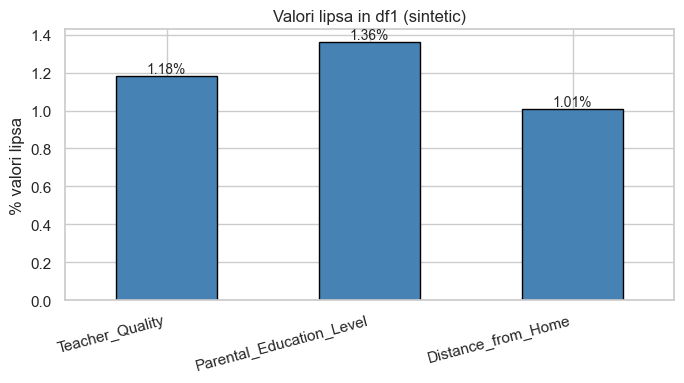

In [153]:
# Vizualizare valori lipsa - df1
fig, ax = plt.subplots(figsize=(7, 4))
missing_pct_df1.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Valori lipsa in df1 (sintetic)')
ax.set_ylabel('% valori lipsa')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [154]:
# Imputare df1 - coloane categorice cu moda (valoarea cea mai frecventa)
# procentul de valori lipsa e mic (1-1.4%), 
# eliminarea randurilor nu e necesara
df1_clean = df1.copy()

cols_cu_lipsa = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_cu_lipsa:
    mode_val = df1_clean[col].mode()[0]
    df1_clean[col] = df1_clean[col].fillna(mode_val)
    print(f"  {col:30s}: imputat cu moda = '{mode_val}'")

print(f"\nValori lipsa ramase in df1_clean: {df1_clean.isnull().sum().sum()}")

# df2 nu are valori lipsa - copie directa
df2_clean = df2.copy()
print(f"Valori lipsa in df2_clean:        {df2_clean.isnull().sum().sum()}")

  Teacher_Quality               : imputat cu moda = 'Medium'
  Parental_Education_Level      : imputat cu moda = 'High School'
  Distance_from_Home            : imputat cu moda = 'Near'

Valori lipsa ramase in df1_clean: 0
Valori lipsa in df2_clean:        0


#### 1.2.2 Valori aberante (Outlieri)

In [155]:
# Detectare outlieri prin IQR
def detectare_outlieri_iqr(df, col):
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((serie < lower) | (serie > upper)).sum()
    return n_out, lower, upper

print("=== Outlieri Dataset 1 (sintetic) ===")
for col in ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Exam_Score']:
    n, low, high = detectare_outlieri_iqr(df1, col)
    print(f"  {col:25s}: {n:4d} outlieri  (interval valid: [{low:.1f}, {high:.1f}])")

print("\n=== Outlieri Dataset 2 (real UCI) ===")
for col in ['absences', 'G1', 'G2', 'G3', 'age', 'studytime', 'failures']:
    n, low, high = detectare_outlieri_iqr(df2_clean, col)
    print(f"  {col:25s}: {n:4d} outlieri  (interval valid: [{low:.1f}, {high:.1f}])")

=== Outlieri Dataset 1 (sintetic) ===
  Hours_Studied            :   43 outlieri  (interval valid: [4.0, 36.0])
  Attendance               :    0 outlieri  (interval valid: [40.0, 120.0])
  Sleep_Hours              :    0 outlieri  (interval valid: [3.0, 11.0])
  Previous_Scores          :    0 outlieri  (interval valid: [25.5, 125.5])
  Exam_Score               :  104 outlieri  (interval valid: [59.0, 75.0])

=== Outlieri Dataset 2 (real UCI) ===
  absences                 :   54 outlieri  (interval valid: [-9.0, 15.0])
  G1                       :    1 outlieri  (interval valid: [3.0, 19.0])
  G2                       :   20 outlieri  (interval valid: [3.0, 19.0])
  G3                       :   54 outlieri  (interval valid: [4.0, 20.0])
  age                      :    2 outlieri  (interval valid: [13.0, 21.0])
  studytime                :   62 outlieri  (interval valid: [-0.5, 3.5])
  failures                 :  183 outlieri  (interval valid: [0.0, 0.0])


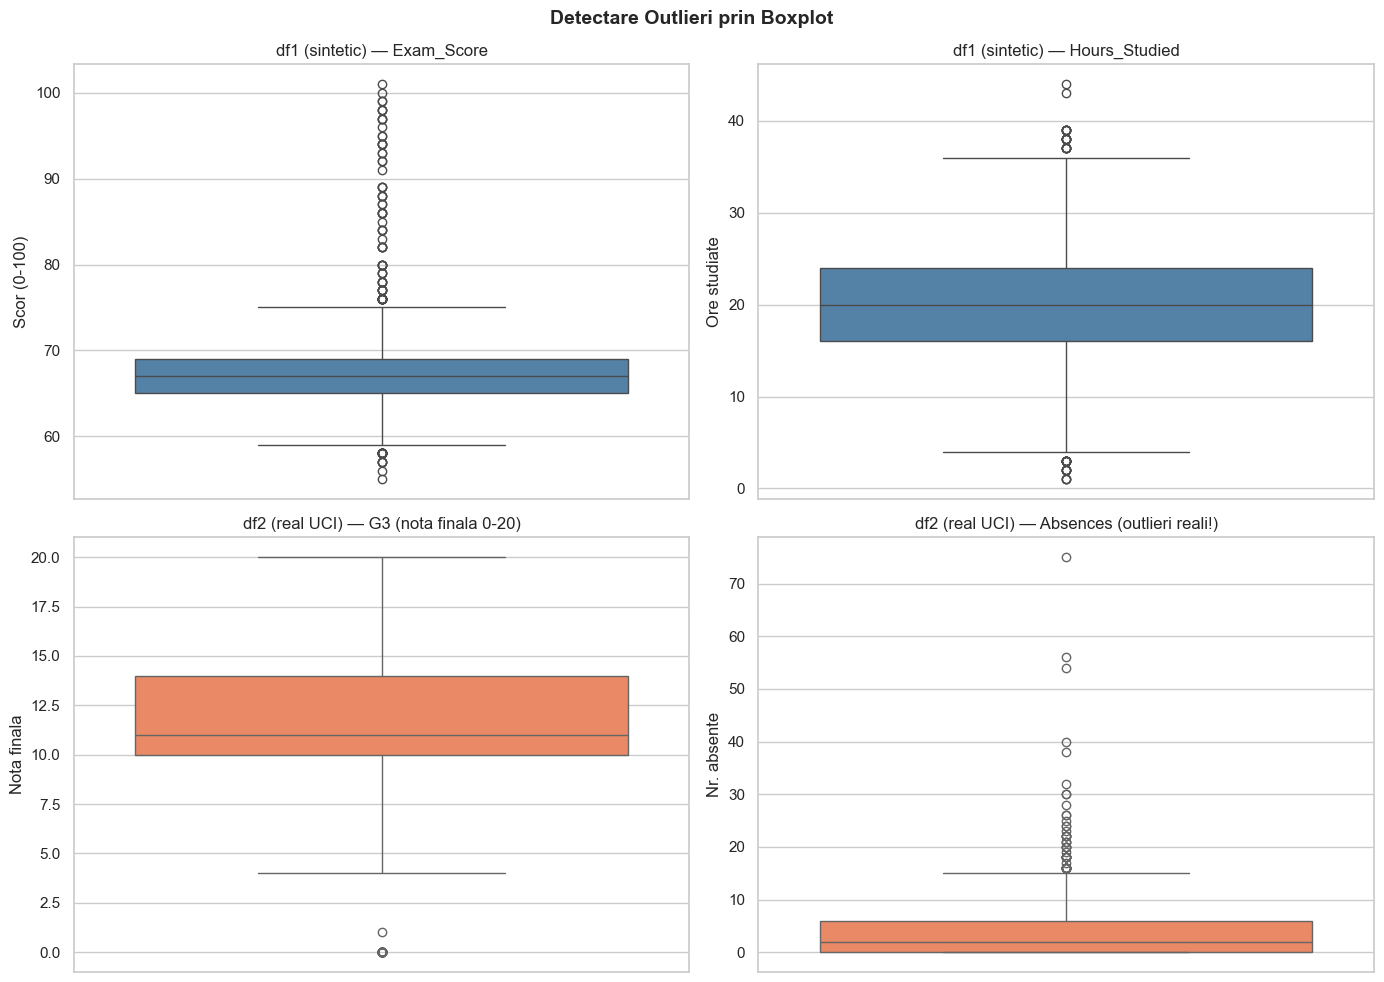

Observatie: df2 are studenti cu pana la 75 absente.
G3=0 apare la 53 studenti -> abandon scolar.

Decizie: pastram toti outlierii — reprezinta cazuri reale, nu erori de masurare.


In [156]:
# Vizualizare outlieri - Boxplot comparativ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df1['Exam_Score'], ax=axes[0][0], color='steelblue')
axes[0][0].set_title('df1 (sintetic) — Exam_Score')
axes[0][0].set_ylabel('Scor (0-100)')

sns.boxplot(y=df1['Hours_Studied'], ax=axes[0][1], color='steelblue')
axes[0][1].set_title('df1 (sintetic) — Hours_Studied')
axes[0][1].set_ylabel('Ore studiate')

sns.boxplot(y=df2_clean['G3'], ax=axes[1][0], color='coral')
axes[1][0].set_title('df2 (real UCI) — G3 (nota finala 0-20)')
axes[1][0].set_ylabel('Nota finala')

sns.boxplot(y=df2_clean['absences'], ax=axes[1][1], color='coral')
axes[1][1].set_title('df2 (real UCI) — Absences (outlieri reali!)')
axes[1][1].set_ylabel('Nr. absente')

plt.suptitle('Detectare Outlieri prin Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Observatie: df2 are studenti cu pana la {int(df2_clean['absences'].max())} absente.")
print(f"G3=0 apare la {(df2_clean['G3']==0).sum()} studenti -> abandon scolar.")
print("\nDecizie: pastram toti outlierii — reprezinta cazuri reale, nu erori de masurare.")

In [157]:
print(f"Observatie: df2 are studenti cu pana la {int(df2_clean['absences'].max())} absente.")
print(f"G3=0 apare la {(df2_clean['G3']==0).sum()} studenti -> abandon scolar.")
print("\nDecizie: pastram toti outlierii — reprezinta cazuri reale, nu erori de masurare.")

Observatie: df2 are studenti cu pana la 75 absente.
G3=0 apare la 53 studenti -> abandon scolar.

Decizie: pastram toti outlierii — reprezinta cazuri reale, nu erori de masurare.


#### 1.2.3 Analiza coloanelor cu variabilitate mica

In [158]:
# Identificam coloanele numerice cu variabilitate mica in df2_clean
# O coloana e "saraca" daca o singura valoare acopera >60% din date
print("=== Variabilitate coloane numerice - df2 (UCI) ===\n")

PRAG_VARIABILITATE = 60.0
variabilitate = []

for col in COLS_NUMERICE_DF2:
    serie = pd.to_numeric(df2_clean[col], errors='coerce').dropna()
    vc = serie.value_counts(normalize=True)
    variabilitate.append({
        'Coloana': col,
        'Valori_unice': serie.nunique(),
        'Valoare_dominanta_%': round(vc.max() * 100, 1),
        'Std': round(serie.std(), 3)
    })

df_variabilitate = pd.DataFrame(variabilitate).sort_values('Valoare_dominanta_%', ascending=False)
display(df_variabilitate)

COLS_SARACE = df_variabilitate[
    df_variabilitate['Valoare_dominanta_%'] > PRAG_VARIABILITATE
]['Coloana'].tolist()

print(f"\nColoane cu valoarea dominanta > {PRAG_VARIABILITATE}%: {COLS_SARACE}")

=== Variabilitate coloane numerice - df2 (UCI) ===



,Coloana,Valori_unice,Valoare_dominanta_%,Std
5,failures,4,82.5,0.656
9,Dalc,5,69.6,0.912
3,traveltime,4,59.7,0.732
6,famrel,5,49.0,0.933
4,studytime,4,48.2,0.834
7,freetime,5,39.1,1.032
10,Walc,5,38.1,1.285
11,health,5,37.8,1.425
12,absences,35,34.4,6.210
8,goout,5,32.1,1.153



Coloane cu valoarea dominanta > 60.0%: ['failures', 'Dalc']


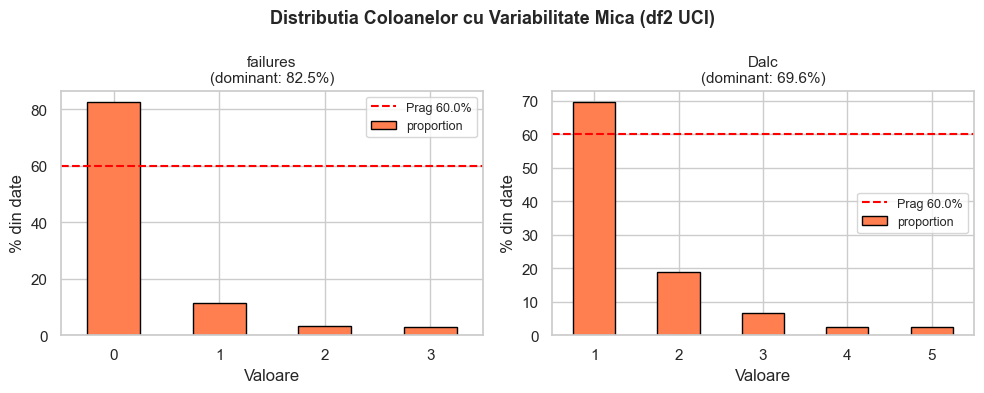

In [159]:
# Vizualizare distributia coloanelor sarace
n_sarace = len(COLS_SARACE)
fig, axes = plt.subplots(1, n_sarace, figsize=(5 * n_sarace, 4))
if n_sarace == 1:
    axes = [axes]

for ax, col in zip(axes, COLS_SARACE):
    serie = pd.to_numeric(df2_clean[col], errors='coerce').dropna()
    vc = serie.value_counts(normalize=True).sort_index() * 100
    vc.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'{col}\n(dominant: {vc.max():.1f}%)', fontsize=11)
    ax.set_ylabel('% din date')
    ax.set_xlabel('Valoare')
    ax.axhline(y=PRAG_VARIABILITATE, color='red', linestyle='--',
               linewidth=1.5, label=f'Prag {PRAG_VARIABILITATE}%')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distributia Coloanelor cu Variabilitate Mica (df2 UCI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

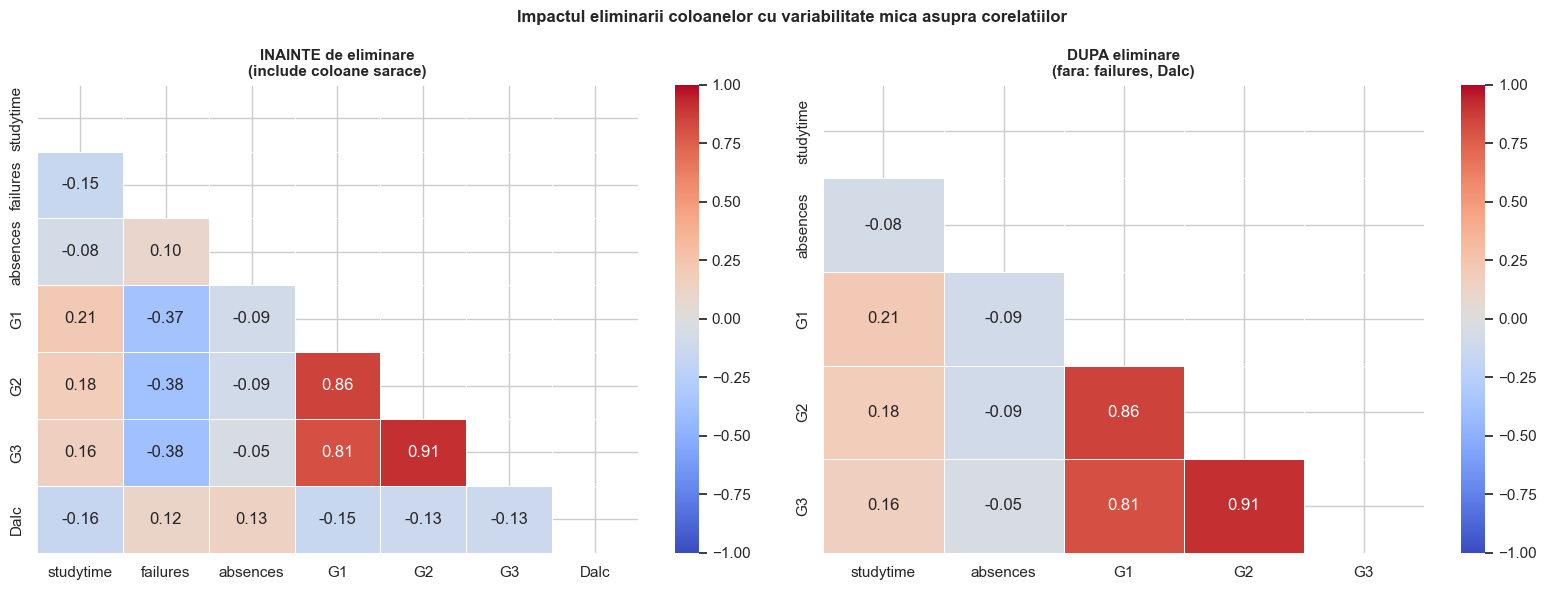

In [160]:
# Comparam matricea de corelatie INAINTE vs DUPA eliminarea coloanelor sarace
COLS_ANALIZA = list(dict.fromkeys(['studytime', 'failures', 'absences', 'G1', 'G2', 'G3'] + COLS_SARACE))
df_before = df2_clean[COLS_ANALIZA].apply(pd.to_numeric, errors='coerce')
df_after  = df_before.drop(columns=COLS_SARACE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_before = df_before.corr()
mask_b = np.triu(np.ones_like(corr_before, dtype=bool))
sns.heatmap(corr_before, mask=mask_b, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('INAINTE de eliminare\n(include coloane sarace)',
                  fontsize=11, fontweight='bold')

corr_after = df_after.corr()
mask_a = np.triu(np.ones_like(corr_after, dtype=bool))
sns.heatmap(corr_after, mask=mask_a, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title(f'DUPA eliminare\n(fara: {", ".join(COLS_SARACE)})',
                  fontsize=11, fontweight='bold')

plt.suptitle('Impactul eliminarii coloanelor cu variabilitate mica asupra corelatiilor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [161]:
print("=== Impact eliminare coloane sarace — corelatii cu G3 ===\n")

corr_g3_before = df_before.corr()['G3'].drop('G3').abs().sort_values(ascending=False)
corr_g3_after  = df_after.corr()['G3'].drop('G3').abs().sort_values(ascending=False)

print("Corelatii cu G3 — INAINTE:")
print(corr_g3_before.to_string())
print("\nCorelatii cu G3 — DUPA eliminare:")
print(corr_g3_after.to_string())

print(f"\nColoane eliminate: {COLS_SARACE}")
print("Concluzie: Corelatiile importante raman neschimbate dupa eliminare.")
print("failures si Dalc nu aduc informatie utila pentru predictia notei finale.")

=== Impact eliminare coloane sarace — corelatii cu G3 ===

Corelatii cu G3 — INAINTE:
G2           0.910743
G1           0.809142
failures     0.383145
studytime    0.161629
Dalc         0.129642
absences     0.045671

Corelatii cu G3 — DUPA eliminare:
G2           0.910743
G1           0.809142
studytime    0.161629
absences     0.045671

Coloane eliminate: ['failures', 'Dalc']
Concluzie: Corelatiile importante raman neschimbate dupa eliminare.
failures si Dalc nu aduc informatie utila pentru predictia notei finale.


### 1.3 Analiza Statistica Descriptiva

In [162]:
print("=== Statistici descriptive — Dataset 1 (sintetic) ===")
display(df1.describe().round(2))

=== Statistici descriptive — Dataset 1 (sintetic) ===


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [163]:
print("=== Statistici descriptive — Dataset 2 (real UCI) ===")
display(df2_clean[['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']].describe().round(2))

=== Statistici descriptive — Dataset 2 (real UCI) ===


,age,studytime,failures,absences,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,16.73,1.97,0.26,4.43,11.21,11.25,11.34
std,1.24,0.83,0.66,6.21,2.98,3.29,3.86
min,15.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,16.00,1.00,0.00,0.00,9.00,9.00,10.00
50%,17.00,2.00,0.00,2.00,11.00,11.00,11.00
75%,18.00,2.00,0.00,6.00,13.00,13.00,14.00
max,22.00,4.00,3.00,75.00,19.00,19.00,20.00


In [164]:
# Distributia variabilelor categorice - df1
print("=== Distributia variabilelor categorice — df1 ===")
for col in df1.select_dtypes(include='str').columns:
    print(f"\n{col}:")
    print(df1[col].value_counts().to_string())

=== Distributia variabilelor categorice — df1 ===

Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319

Internet_Access:
Internet_Access
Yes    6108
No      499

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269

Teacher_Quality:
Teacher_Quality
Medium    3925
High      1947
Low        657

School_Type:
School_Type
Public     4598
Private    2009

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes     695

Parental_Education_Level:
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305

Distance_from_Home:
Distance_from_Home
Near        3884
Moderate    1998
F

In [165]:
# Distributia variabilelor categorice - df2 (selectie relevanta)
print("=== Distributia variabilelor categorice — df2 (selectie) ===")
for col in ['sex', 'school', 'address', 'internet', 'higher', 'subject']:
    print(f"\n{col}:")
    print(df2_clean[col].value_counts().to_string())

=== Distributia variabilelor categorice — df2 (selectie) ===

sex:
sex
F    591
M    453

school:
school
GP    772
MS    272

address:
address
U    759
R    285

internet:
internet
yes    827
no     217

higher:
higher
yes    955
no      89

subject:
subject
portuguese    649
math          395


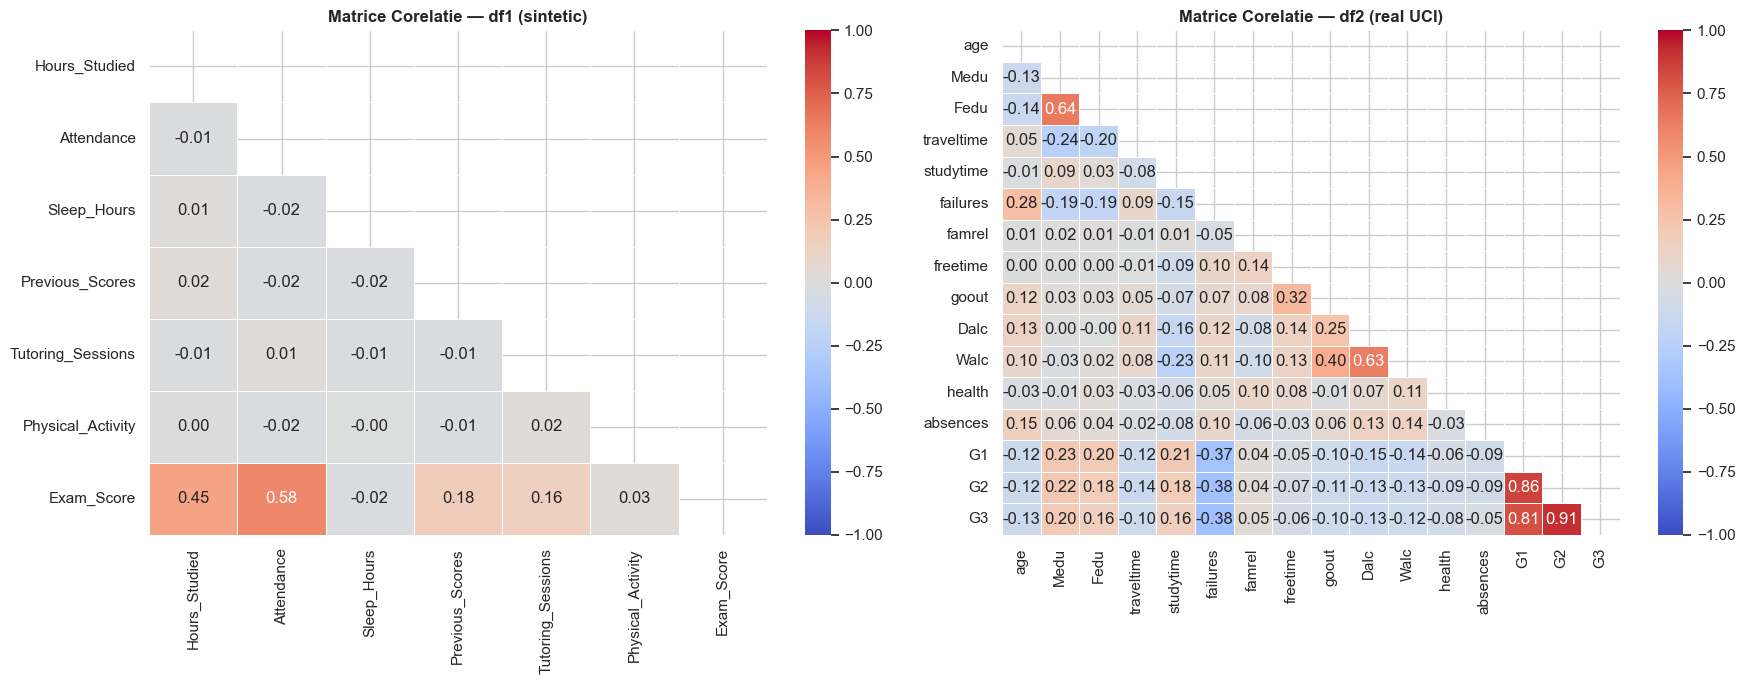

Top corelatii cu nota finala:
  df1 (Exam_Score): {'Attendance': 0.581, 'Hours_Studied': 0.445, 'Previous_Scores': 0.175}
  df2 (G3): {'G2': 0.911, 'G1': 0.809, 'failures': 0.383}


In [166]:
# Matrice de corelatie comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# df1
corr1 = df1.select_dtypes(include=np.number).corr()
mask1 = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1, mask=mask1, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Matrice Corelatie — df1 (sintetic)', fontsize=12, fontweight='bold')

# df2
corr2 = df2_clean[COLS_NUMERICE_DF2].corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title('Matrice Corelatie — df2 (real UCI)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Top corelatii cu nota finala:")
print("  df1 (Exam_Score):",
      corr1['Exam_Score'].drop('Exam_Score').abs().sort_values(ascending=False).head(3).round(3).to_dict())
print("  df2 (G3):",
      corr2['G3'].drop('G3').abs().sort_values(ascending=False).head(3).round(3).to_dict())

### 1.4 Vizualizari Exploratorii

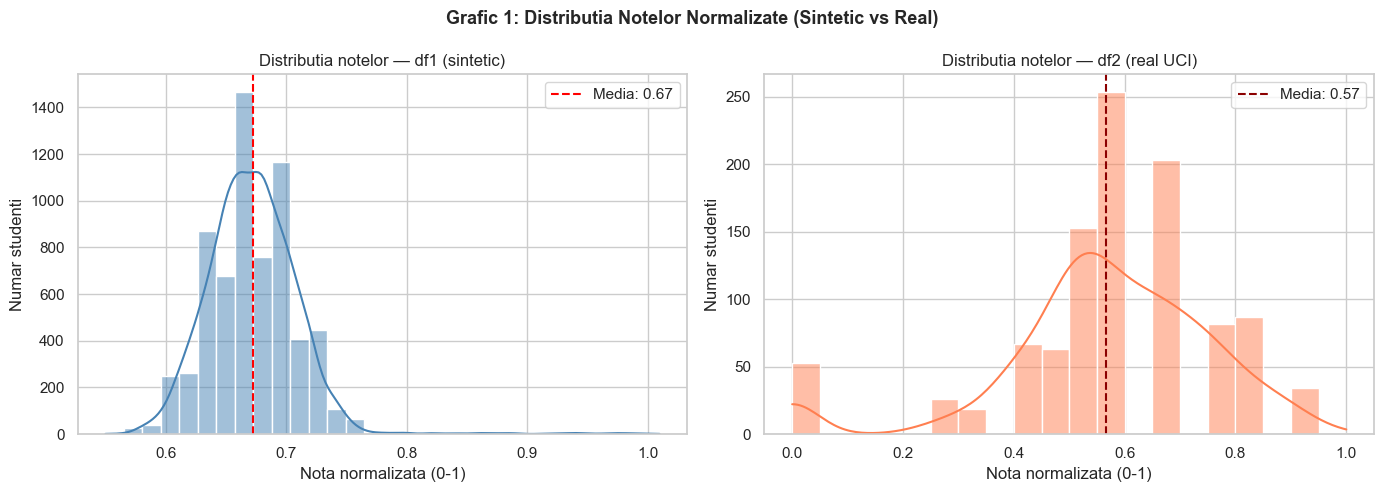

Interpretare: df1 (sintetic) are o distributie apropiata de normala, centrata ~0.67.
df2 (real) are o distributie asimetrica cu un spike la 0 (abandon scolar).


In [167]:
# --- Grafic 1: Distributia notelor normalizate — sintetic vs real ---
score_norm_df1 = df1['Exam_Score'] / 100.0
score_norm_df2 = df2_clean['G3'] / 20.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(score_norm_df1, ax=axes[0], kde=True, color='steelblue', bins=30)
axes[0].axvline(score_norm_df1.mean(), color='red', linestyle='--',
                label=f'Media: {score_norm_df1.mean():.2f}')
axes[0].set_title('Distributia notelor — df1 (sintetic)', fontsize=12)
axes[0].set_xlabel('Nota normalizata (0-1)')
axes[0].set_ylabel('Numar studenti')
axes[0].legend()

sns.histplot(score_norm_df2, ax=axes[1], kde=True, color='coral', bins=20)
axes[1].axvline(score_norm_df2.mean(), color='darkred', linestyle='--',
                label=f'Media: {score_norm_df2.mean():.2f}')
axes[1].set_title('Distributia notelor — df2 (real UCI)', fontsize=12)
axes[1].set_xlabel('Nota normalizata (0-1)')
axes[1].set_ylabel('Numar studenti')
axes[1].legend()

plt.suptitle('Grafic 1: Distributia Notelor Normalizate (Sintetic vs Real)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretare: df1 (sintetic) are o distributie apropiata de normala, centrata ~0.67.")
print("df2 (real) are o distributie asimetrica cu un spike la 0 (abandon scolar).")

**Distributia notelor:**

**df1 (SINTETIC):**
- Distributie aproximativ normala, centrata la **0.67** (67/100)
- Variatie mica (std=0.039) — specific datelor generate artificial
- *"Prea curata"* pentru date reale: aproape toti studentii au note intre 0.60-0.75
- Coada dreapta subtire cu cateva valori extreme, inclusiv **Exam_Score=101** — eroare de generare (scala declarata e 0-100)

**df2 (REAL UCI):**
- Distributie neuniforma, larga, fara un varf clar dominant
- Spike vizibil la **0.0** — studenti cu abandon scolar sau neprezentati la examen
- Distributie bimodala: un grup mic la 0 si masa principala intre 0.45-0.75
- Variatie mult mai mare (std=0.193) — reflecta diversitatea reala a studentilor

**Concluzie:**
Datele sintetice forteaza o distributie normala artificiala, in timp ce datele reale
reflecta variabilitatea naturala a performantei academice.
KS Test confirma matematic aceasta diferenta (**statistica=0.5882, p≈0**) —
distributiile sunt semnificativ diferite, ceea ce va fi relevant in Etapa 3 la limitarile analizei.

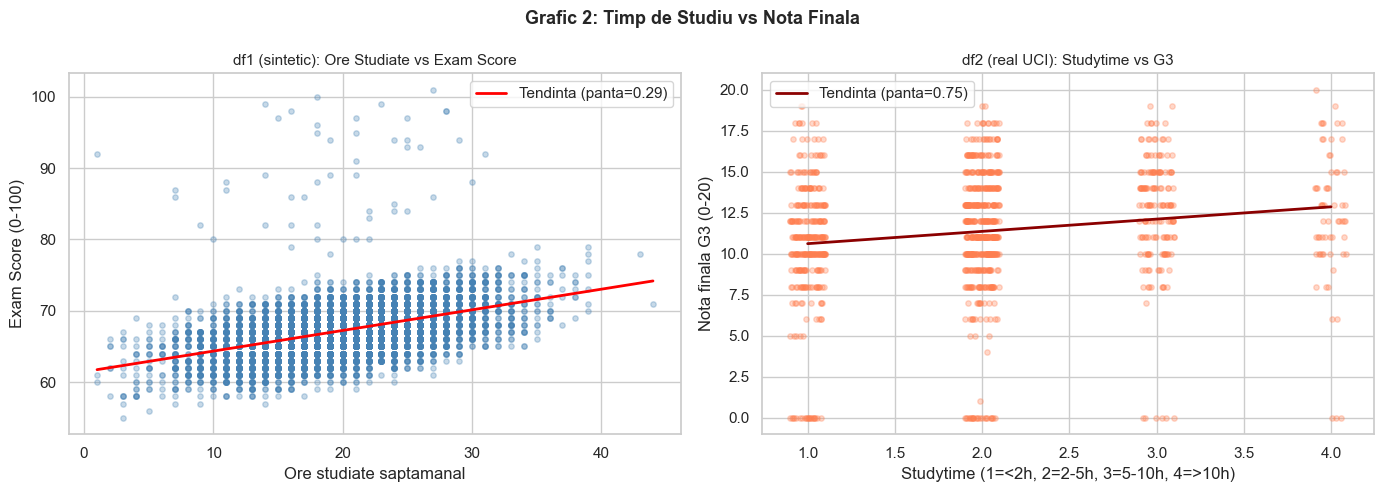

Corelatie Pearson timp studiu - nota: df1=0.445, df2=0.162
Interpretare: Corelatie pozitiva in ambele seturi, dar moderata — studiul ajuta, nu e singurul factor.


In [168]:
# --- Grafic 2: Timp de studiu vs nota ---
# Conversie explicita si eliminare NaN pentru df2
st  = pd.to_numeric(df2_clean['studytime'], errors='coerce')
g3  = pd.to_numeric(df2_clean['G3'],        errors='coerce')
mask = st.notna() & g3.notna()
st_c, g3_c = st[mask], g3[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# df1
axes[0].scatter(df1['Hours_Studied'], df1['Exam_Score'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df1['Hours_Studied'], df1['Exam_Score'], 1)
x = np.linspace(df1['Hours_Studied'].min(), df1['Hours_Studied'].max(), 100)
axes[0].plot(x, m * x + b, color='red', linewidth=2, label=f'Tendinta (panta={m:.2f})')
axes[0].set_title('df1 (sintetic): Ore Studiate vs Exam Score', fontsize=11)
axes[0].set_xlabel('Ore studiate saptamanal')
axes[0].set_ylabel('Exam Score (0-100)')
axes[0].legend()

# df2
jitter = np.random.uniform(-0.1, 0.1, len(st_c))
axes[1].scatter(st_c + jitter, g3_c, alpha=0.3, color='coral', s=15)
m2, b2 = np.polyfit(st_c, g3_c, 1)
x2 = np.linspace(1, 4, 100)
axes[1].plot(x2, m2 * x2 + b2, color='darkred', linewidth=2, label=f'Tendinta (panta={m2:.2f})')
axes[1].set_title('df2 (real UCI): Studytime vs G3', fontsize=11)
axes[1].set_xlabel('Studytime (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[1].set_ylabel('Nota finala G3 (0-20)')
axes[1].legend()

plt.suptitle('Grafic 2: Timp de Studiu vs Nota Finala', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr1 = df1['Hours_Studied'].corr(df1['Exam_Score'])
corr2 = st_c.corr(g3_c)
print(f"Corelatie Pearson timp studiu - nota: df1={corr1:.3f}, df2={corr2:.3f}")
print("Interpretare: Corelatie pozitiva in ambele seturi, dar moderata — studiul ajuta, nu e singurul factor.")

**Timp de Studiu vs Nota Finala:**

**df1 (SINTETIC):**
- Tendinta pozitiva clara, panta=0.29 — fiecare ora suplimentara adauga ~0.29 puncte la scor
- Relatia e **liniara si consistenta** de-a lungul intregului interval (1-44 ore)
- Variabilitatea e mica si uniforma — din nou, tipic pentru date sintetice controlate
- Corelatie Pearson = **0.445** — relatie moderata spre puternica

**df2 (REAL UCI):**
- Tendinta pozitiva dar mult mai slaba, panta=0.75 pe o scala 0-20 (echivalent ~0.04 pe scala 0-1)
- Variabilitatea e **enorma** la fiecare nivel de studytime — studenti cu G3=0 si G3=18 coexista la acelasi studytime=2
- Jitter-ul aplicat evidentiaza ca majoritatea studentilor se concentreaza la studytime=1 si 2
- Corelatie Pearson = **0.162** — relatie foarte slaba

**Concluzie:**
Ambele seturi confirma ca mai mult studiu → note mai bune, insa **magnitudinea difera dramatic**.
In datele reale, studytime singur nu explica performanta — un student care studiaza mult
poate lua note mici din alte motive (dificultatea materiei, probleme personale, etc.).
Datele sintetice simplifica excesiv aceasta relatie.

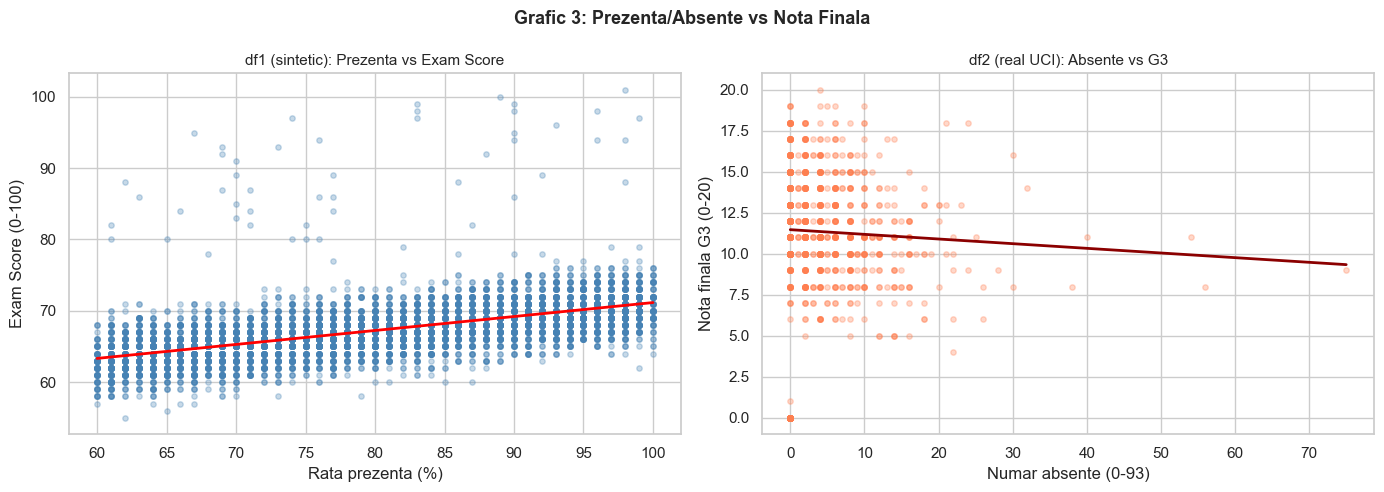

Corelatie prezenta/absente - nota: df1=0.581, df2=-0.046
Interpretare: Prezenta are impact puternic in ambele seturi (inversata: mai multe absente = nota mai mica).


In [169]:
# --- Grafic 3: Prezenta/Absente vs nota ---
ab = pd.to_numeric(df2_clean['absences'], errors='coerce')
g3 = pd.to_numeric(df2_clean['G3'],       errors='coerce')
mask = ab.notna() & g3.notna()
ab_c, g3_c = ab[mask], g3[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# df1
axes[0].scatter(df1['Attendance'], df1['Exam_Score'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df1['Attendance'], df1['Exam_Score'], 1)
x = np.linspace(df1['Attendance'].min(), df1['Attendance'].max(), 100)
axes[0].plot(x, m * x + b, color='red', linewidth=2)
axes[0].set_title('df1 (sintetic): Prezenta vs Exam Score', fontsize=11)
axes[0].set_xlabel('Rata prezenta (%)')
axes[0].set_ylabel('Exam Score (0-100)')

# df2
axes[1].scatter(ab_c, g3_c, alpha=0.3, color='coral', s=15)
m2, b2 = np.polyfit(ab_c, g3_c, 1)
x2 = np.linspace(0, ab_c.max(), 100)
axes[1].plot(x2, m2 * x2 + b2, color='darkred', linewidth=2)
axes[1].set_title('df2 (real UCI): Absente vs G3', fontsize=11)
axes[1].set_xlabel('Numar absente (0-93)')
axes[1].set_ylabel('Nota finala G3 (0-20)')

plt.suptitle('Grafic 3: Prezenta/Absente vs Nota Finala', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr1 = df1['Attendance'].corr(df1['Exam_Score'])
corr2 = ab_c.corr(g3_c)
print(f"Corelatie prezenta/absente - nota: df1={corr1:.3f}, df2={corr2:.3f}")
print("Interpretare: Prezenta are impact puternic in ambele seturi (inversata: mai multe absente = nota mai mica).")

**Prezenta/Absente vs Nota Finala:**

**df1 (SINTETIC):**
- Tendinta pozitiva clara — mai multa prezenta → note mai mari
- Relatia e **liniara si uniforma** pe tot intervalul 60-100%
- Variabilitatea e mica si constanta — punctele sunt distribuite uniform in jurul liniei de tendinta
- Corelatie Pearson = **0.581** — cel mai puternic predictor din df1

**df2 (REAL UCI):**
- Tendinta negativa slaba — mai multe absente → note putin mai mici
- Variabilitatea e **extrem de mare** mai ales la 0-10 absente: studenti cu G3=0 si G3=19 coexista
- Masa principala de date e concentrata intre 0-15 absente — outlieri vizibili spre dreapta (pana la 75)
- Corelatie Pearson = **-0.046** — practic inexistenta

**Concluzie:**
Aceasta este cea mai interesanta discrepanta dintre cele doua seturi.
In datele sintetice, prezenta e **factorul dominant** (corelatie 0.581).
In realitate, absenta singura nu determina nota — un student cu 0 absente
poate lua G3=0, iar unul cu 15 absente poate lua G3=19.
Acest lucru sugereaza ca in realitate **contextul individual conteaza mai mult**
decat simpla prezenta fizica la ore, ceea ce datele sintetice nu captureaza.

C:\Users\Bogdan Petrea\AppData\Local\Temp\ipykernel_16564\3280482689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_g_df1, x='Gender', y='Exam_Score',
C:\Users\Bogdan Petrea\AppData\Local\Temp\ipykernel_16564\3280482689.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_g_df2, x='sex', y='G3',


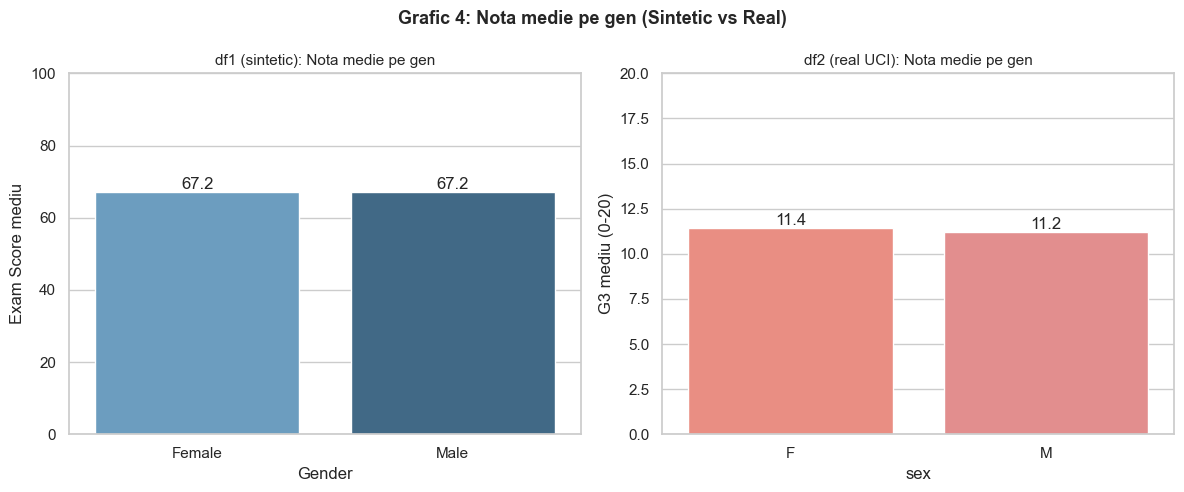

Interpretare: Diferentele intre genuri sunt minime in ambele seturi —
genul nu este un predictor puternic al performantei academice.


In [170]:
# --- Grafic 4: Nota medie pe gen ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mean_g_df1 = df1.groupby('Gender')['Exam_Score'].mean().reset_index()
sns.barplot(data=mean_g_df1, x='Gender', y='Exam_Score',
            ax=axes[0], palette='Blues_d', errorbar='sd')
axes[0].set_title('df1 (sintetic): Nota medie pe gen', fontsize=11)
axes[0].set_ylabel('Exam Score mediu')
axes[0].set_ylim(0, 100)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

mean_g_df2 = df2_clean.groupby('sex')['G3'].mean().reset_index()
sns.barplot(data=mean_g_df2, x='sex', y='G3',
            ax=axes[1], palette=['salmon', 'lightcoral'], errorbar='sd')
axes[1].set_title('df2 (real UCI): Nota medie pe gen', fontsize=11)
axes[1].set_ylabel('G3 mediu (0-20)')
axes[1].set_ylim(0, 20)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

plt.suptitle('Grafic 4: Nota medie pe gen (Sintetic vs Real)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretare: Diferentele intre genuri sunt minime in ambele seturi —")
print("genul nu este un predictor puternic al performantei academice.")

**Nota medie pe gen:**

**df1 (SINTETIC):**
- Mediile sunt **identice** — 67.2 pentru ambele genuri
- Egalitatea perfecta e un semn clar ca datele au fost generate cu un **bias intentionat spre echilibru**
- In date reale, o egalitate perfecta pana la prima zecimala e practic imposibila

**df2 (REAL UCI):**
- Diferenta minima — F=**11.4** vs M=**11.2** (diferenta de 0.2 puncte pe scala 0-20)
- Diferenta e atat de mica incat nu poate fi considerata semnificativa statistic
- Reflecta realitatea: genul nu e un factor determinant al performantei academice

**Concluzie:**
Ambele seturi confirma **Ipoteza 2** — genul nu este un predictor relevant al performantei.
Totusi, egalitatea perfecta din df1 (67.2 = 67.2) este un artefact al generarii sintetice,
nu o reflectare a realitatii. In date reale exista intotdeauna o mica variatie naturala,
chiar daca aceasta nu e semnificativa statistic.
Vom confirma aceasta ipoteza printr-un **t-test** in Etapa 2.

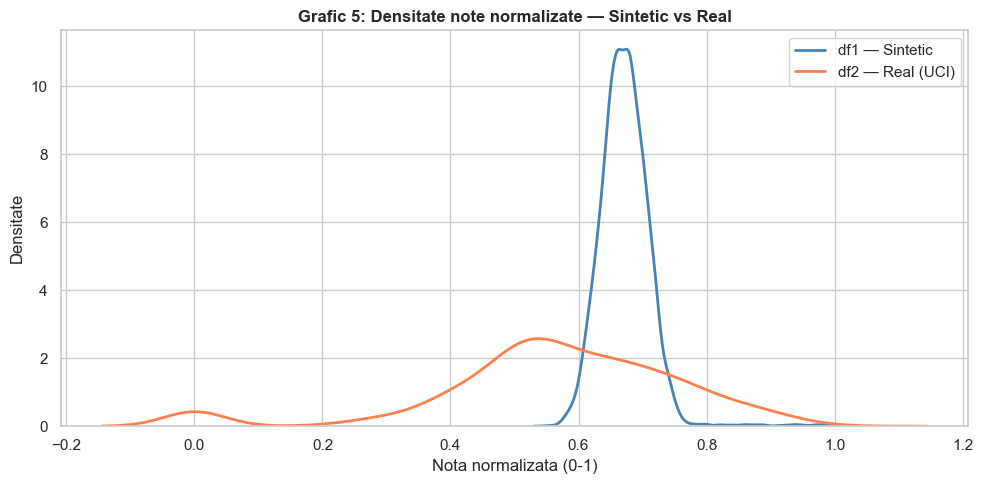

Kolmogorov-Smirnov Test:
  Statistica KS : 0.5882
  p-value        : 0.000000
  Concluzie: Distributiile sunt SEMNIFICATIV DIFERITE (p < 0.05)
  => Datele sintetice nu repliceaza fidel distributia reala a notelor.


In [171]:
# --- Grafic 5: KDE comparativ + KS Test (sintetic vs real) ---
score_norm_df1 = df1['Exam_Score'] / 100.0
score_norm_df2 = pd.to_numeric(df2_clean['G3'], errors='coerce').dropna() / 20.0

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(score_norm_df1, ax=ax, color='steelblue', linewidth=2, label='df1 — Sintetic')
sns.kdeplot(score_norm_df2, ax=ax, color='coral',     linewidth=2, label='df2 — Real (UCI)')
ax.set_title('Grafic 5: Densitate note normalizate — Sintetic vs Real',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nota normalizata (0-1)')
ax.set_ylabel('Densitate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.ks_2samp(score_norm_df1, score_norm_df2)
print(f"Kolmogorov-Smirnov Test:")
print(f"  Statistica KS : {ks_stat:.4f}")
print(f"  p-value        : {ks_p:.6f}")
if ks_p < 0.05:
    print("  Concluzie: Distributiile sunt SEMNIFICATIV DIFERITE (p < 0.05)")
    print("  => Datele sintetice nu repliceaza fidel distributia reala a notelor.")
else:
    print("  Concluzie: Nu exista diferente semnificative intre distributii.")

**Densitate note normalizate (KDE) + KS Test:**

**Grafic:**
- **df1 (albastru):** varf extrem de ingust si inalt la 0.67 — distributie artificiala, 
  aproape toti studentii au note intre 0.60-0.75. Densitatea maxima ~11 arata cat de 
  concentrata e distributia sintetica
- **df2 (portocaliu):** curba larga si joasa, cu doua componente vizibile:
  - Un mic varf la ~0.0 (studentii cu abandon / G3=0)
  - Masa principala intre 0.45-0.80, mult mai dispersata

**KS Test:**
- Statistica = **0.5882** — distanta maxima dintre cele doua distributii cumulative
- p-value = **0.000000** — practic zero
- O statistica KS de ~0.59 este **extrem de mare** (scala 0-1), confirmand ca 
  cele doua distributii nu au nicio similitudine semnificativa

**Concluzie:**
Acesta este graficul care rezuma cel mai bine intreaga analiza comparativa.
Datele sintetice si cele reale **descriu lumi diferite** din punct de vedere al distributiei notelor:
- Sinteticul presupune ca toti studentii sunt "mediocru buni" (clustered la 0.67)
- Realitatea arata o populatie **eterogena** — de la abandon total la excelenta

Aceasta diferenta fundamentala va avea implicatii directe asupra performantei
modelelor ML in Etapa 2: un model antrenat pe df1 va performa slab pe df2 si viceversa.

### 1.5 Formularea Ipotezelor

*Pe baza analizei exploratorii, formulam urmatoarele ipoteze care vor fi testate in Etapa 2:*


**Ipoteza 1:** Prezenta la cursuri si orele de studiu sunt cei mai importanti factori pentru predictia notei finale in datele sintetice, dar nu si in datele reale.

*Justificare:* In EDA am observat o discrepanta semnificativa intre cele doua seturi:
- `Attendance` ↔ `Exam_Score` in df1 = **0.581** (corelatie puternica)
- `absences` ↔ `G3` in df2 = **-0.046** (corelatie aproape inexistenta)

Aceasta diferenta sugereaza ca datele sintetice **supraestimeaza impactul prezentei**, in timp ce in realitate alti factori (note anterioare, corigente) au un rol mai important. Vom testa aceasta ipoteza prin **feature importance** in Random Forest (Etapa 2).

---

**Ipoteza 2:** Factorii socio-demografici (gen, tip scoala, acces internet, venit familial, implicarea parintilor) au impact semnificativ mai mic decat factorii comportamentali (ore studiu, prezenta) asupra performantei academice.

*Justificare:* Matricea de corelatie din df1 arata ca `Hours_Studied` (0.445) si `Attendance` (0.581) sunt cei mai puternici predictori, depasind clar factorii sociali. Graficul 4 confirma ca genul nu are practic niciun impact — mediile sunt identice (67.2 vs 67.2 in df1, 11.4 vs 11.2 in df2). In df2, `failures` (0.383) e singurul factor social relevant, dar si acesta reflecta mai degraba comportamentul academic anterior decat contextul social. Vom verifica prin **regresie liniara si feature importance** in Etapa 2.

---

**Ipoteza 3:** Desi distributiile notelor difera semnificativ intre datele sintetice si cele reale, factorii determinanti ai performantei sunt partial consistenti intre cele doua seturi.

*Justificare:* KS Test a aratat distributii fundamental diferite (statistica=0.5882, p≈0) — df1 are o distributie artificiala, extrem de ingusta, centrata la 0.67, in timp ce df2 are o distributie larga cu coada la 0 (abandon scolar). Cu toate acestea, corelatiile cheie merg in aceeasi directie in ambele seturi: studiul mai mult → note mai bune, absente mai multe → note mai mici. Diferenta e in **magnitudine**, nu in **directie**. Vom compara **feature importance** intre modele antrenate pe df1 vs df2 in Etapa 2.

---

**Ipoteza 4:** Somnul suficient (7-8 ore) are o influenta pozitiva, dar moderata, asupra performantei academice.

*Justificare:* `Sleep_Hours` are corelatie mica cu `Exam_Score` in df1 (sub 0.05 in matricea de corelatie), ceea ce sugereaza un efect prezent dar moderat. In df2 nu avem o coloana echivalenta directa. Vom testa daca somnul ramane un predictor semnificativ in modele sau daca este eliminat automat in procesul de selectie a feature-urilor in Etapa 2.

---
## Etapa 2: Modelarea Datelor

In aceasta etapa vom aplica tehnici de invatare automata pentru modelarea datelor.

**Obiective:**
- Implementarea a cel putin 2-3 modele de regresie SAU clasificare
- Evaluarea si compararea performantei modelelor

**Punctaj: 15 puncte**
- Pregatirea datelor pentru modelare: 3p
- Implementarea modelelor: 6p
- Evaluarea si compararea: 4p
- Interpretarea rezultatelor: 2p

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [173]:
# TODO: Definiti variabila target
y = None  # ex: df1['Exam_Score'] sau df2_clean['G3']

print(f"Target: {y.name if hasattr(y, 'name') else 'nedefinit'}")
print(f"Tip problema: {'Regresie' if y.dtype in ['int64', 'float64'] else 'Clasificare'}")

Target: nedefinit


AttributeError: 'NoneType' object has no attribute 'dtype'

In [ ]:
# TODO: Selectati features
feature_columns = []
X = None

print(f"Features selectate: {len(feature_columns)}")
print(f"Coloane: {feature_columns}")
print(X.dtypes)

In [ ]:
# TODO: Tratati variabilele categorice + train/test split
X_train, X_test, y_train, y_test = None, None, None, None

print(f"Date de antrenare: {X_train.shape[0]} exemple")
print(f"Date de test:      {X_test.shape[0]} exemple")

### 2.2 Implementarea Modelelor

Implementati **minim 2-3 modele** din categoriile de mai jos.

### Pentru REGRESIE (target numeric continuu):
| Model | Import | Cand e potrivit |
|-------|--------|----------------|
| Linear Regression | `from sklearn.linear_model import LinearRegression` | Relatii liniare simple |
| Ridge/Lasso | `from sklearn.linear_model import Ridge, Lasso` | Cand aveti multe features |
| Random Forest | `from sklearn.ensemble import RandomForestRegressor` | Relatii complexe, non-liniare |
| Gradient Boosting | `from sklearn.ensemble import GradientBoostingRegressor` | Performanta ridicata |

### Pentru CLASIFICARE (target categoric):
| Model | Import | Cand e potrivit |
|-------|--------|----------------|
| Logistic Regression | `from sklearn.linear_model import LogisticRegression` | Clasificare binara simpla |
| Random Forest | `from sklearn.ensemble import RandomForestClassifier` | Clasificare complexa |
| Gradient Boosting | `from sklearn.ensemble import GradientBoostingClassifier` | Performanta ridicata |

In [ ]:
model_1 = None
y_pred_1 = None

model_2 = None
y_pred_2 = None

model_3 = None  # Optional — pentru punctaj maxim
y_pred_3 = None

### 2.3 Evaluarea si Compararea Modelelor

#### Metrici pentru REGRESIE:
| Metrica | Functie | Interpretare |
|---------|---------|-------------|
| R² | `r2_score(y_test, y_pred)` | Cat de bine explica modelul variatia (1 = perfect) |
| RMSE | `np.sqrt(mean_squared_error(y_test, y_pred))` | Eroarea medie |
| MAE | `mean_absolute_error(y_test, y_pred)` | Eroarea medie absoluta |

#### Metrici pentru CLASIFICARE:
| Metrica | Functie | Interpretare |
|---------|---------|-------------|
| Accuracy | `accuracy_score(y_test, y_pred)` | Proportia predictiilor corecte |
| Classification Report | `classification_report(y_test, y_pred)` | Precision, Recall, F1 |
| Confusion Matrix | `confusion_matrix(y_test, y_pred)` | Distributia predictiilor |

In [ ]:
print("=== Model 1: [Nume] ===")
# ...

In [ ]:
print("=== Model 2: [Nume] ===")
# ...

In [ ]:
# TODO: Tabel comparativ modele
# results = pd.DataFrame({
#     'Model': ['Model 1', 'Model 2', 'Model 3'],
#     'R2':   [r2_1,   r2_2,   r2_3],
#     'RMSE': [rmse_1, rmse_2, rmse_3],
#     'MAE':  [mae_1,  mae_2,  mae_3]
# }).sort_values('R2', ascending=False)

results = None
results

In [ ]:
# TODO: Vizualizati comparatia
# results.plot(kind='bar', x='Model', figsize=(10, 5))
# plt.title('Comparatie modele')
# plt.tight_layout()
# plt.show()

### 2.4 Interpretare si Concluzii

#### 2.4.1 Care model a performat cel mai bine si de ce?
- Modelul cu cea mai buna performanta este: ...
- Metricile lui sunt: ...
- Posibile explicatii: ...

#### 2.4.2 Ce features sunt cele mai importante pentru predictie?
- Top 3 features importante: ...
- Interpretare: ...

In [ ]:
# OPTIONAL: Feature importance (pentru modele bazate pe arbori)
# importances = model.feature_importances_
# feature_imp = pd.DataFrame({'feature': feature_columns, 'importance': importances})
# feature_imp.sort_values('importance', ascending=False).head(10).plot(kind='barh')
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

#### 2.4.3 Care sunt limitarile modelelor voastre?
- Limitari ale datelor: ...
- Limitari ale modelelor: ...
- Ce ati putea imbunatati: ...

#### 2.4.4 Recomandari pentru continuare
- ...

---
## Etapa 3: Recomandari si Concluzii

### PRINCIPALELE DESCOPERIRI:

#### 1. FACTORI DETERMINANTI:
*TODO*

#### 2. COMPARATIE SINTETIC vs REAL:
- Distributiile notelor difera semnificativ (confirmat prin KS Test in Etapa 1)
- Corelatiile cheie (prezenta, studiu) se regasesc in ambele seturi
- Coloanele cu variabilitate mica din df2 (ex: Dalc) nu aduc informatie utila

*TODO — completati cu observatiile voastre*

#### 3. PREDICTIE SI CLASIFICARE:
- Modelele ... ofera cea mai buna performanta
- Clasificarea grupurilor cu risc ridicat este posibila cu acuratete ...

*TODO*

### LIMITARI:
- `df1` este sintetic — relatiile sunt generate programatic, nu observate in realitate
- `df2` are dimensiune mica (1044 randuri) si este limitat la doua scoli portugheze
- Factori contextuali dificil de cuantificat (climat scolar, calitatea profesorilor)
- Necesitatea validarii pe date din alte tari / sisteme educationale

*TODO — adaugati limitarile identificate de voi*

### RECOMANDARI PENTRU CONTINUARE:
- Validarea pe date reale dintr-un context local (ex: scoli romanesti)
- Includerea mai multor variabile contextuale (resurse scoala, calitatea profesorilor)
- Modele de deep learning pentru capturarea relatiilor complexe
- Analiza longitudinala (G1 → G2 → G3) disponibila in UCI dar neexploatata complet

*TODO — adaugati recomandarile voastre*